# ⚡ Credit Card Fraud Detection – XGBoost
**It22092039**

| Item | Detail |
|------|--------|
| Algorithm | XGBoost (Extreme Gradient Boosting) |
| Dataset | [Kaggle – Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

## ⚙️ Step 1 — Install & Import Libraries

In [1]:
# XGBoost is pre-installed on Colab; imbalanced-learn is not
!pip install imbalanced-learn --quiet

import xgboost as xgb
print(f'✅ XGBoost version : {xgb.__version__}')
print('✅ imbalanced-learn installed')

✅ XGBoost version : 3.2.0
✅ imbalanced-learn installed


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__} | XGBoost {xgb.__version__}')

✅ All libraries imported
   NumPy 2.0.2 | Pandas 2.2.2 | XGBoost 3.2.0


## 📂 Step 2 — Load Dataset


In [3]:
# ── OPTION A: Upload from computer ───────────────────────────────────────────
from google.colab import files
print('⬆️  Select creditcard.csv from your computer in the dialog below.')
uploaded = files.upload()
print('✅ Uploaded:', list(uploaded.keys()))

⬆️  Select creditcard.csv from your computer in the dialog below.


Saving creditcard.csv to creditcard.csv
✅ Uploaded: ['creditcard.csv']


In [4]:
# ── OPTION B: Load from Google Drive (skip if you used Option A) ─────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_PATH = '/content/drive/MyDrive/creditcard.csv'  # update path if needed

In [5]:
df = pd.read_csv('creditcard.csv')
# If using Drive: df = pd.read_csv(DRIVE_PATH)

print(f'✅ Dataset loaded')
print(f'   Shape   : {df.shape}')
print(f'   Memory  : {df.memory_usage(deep=True).sum()/1024**2:.1f} MB')
df.head(3)

✅ Dataset loaded
   Shape   : (284807, 31)
   Memory  : 67.4 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 🔍 Step 3 — Exploratory Data Analysis (EDA)

In [6]:
total      = len(df)
fraud_cnt  = df['Class'].sum()
legit_cnt  = total - fraud_cnt
fraud_pct  = fraud_cnt / total * 100

print('=== Dataset Overview ===')
print(f'Total transactions  : {total:,}')
print(f'Legitimate          : {legit_cnt:,} ({100-fraud_pct:.2f}%)')
print(f'Fraud               : {fraud_cnt:,} ({fraud_pct:.4f}%)')
print(f'Missing values      : {df.isnull().sum().sum()}')
print(f'\nAmount – Legitimate : mean=${df[df.Class==0].Amount.mean():.2f}, max=${df[df.Class==0].Amount.max():.2f}')
print(f'Amount – Fraud      : mean=${df[df.Class==1].Amount.mean():.2f}, max=${df[df.Class==1].Amount.max():.2f}')

=== Dataset Overview ===
Total transactions  : 284,807
Legitimate          : 284,315 (99.83%)
Fraud               : 492 (0.1727%)
Missing values      : 0

Amount – Legitimate : mean=$88.29, max=$25691.16
Amount – Fraud      : mean=$122.21, max=$2125.87


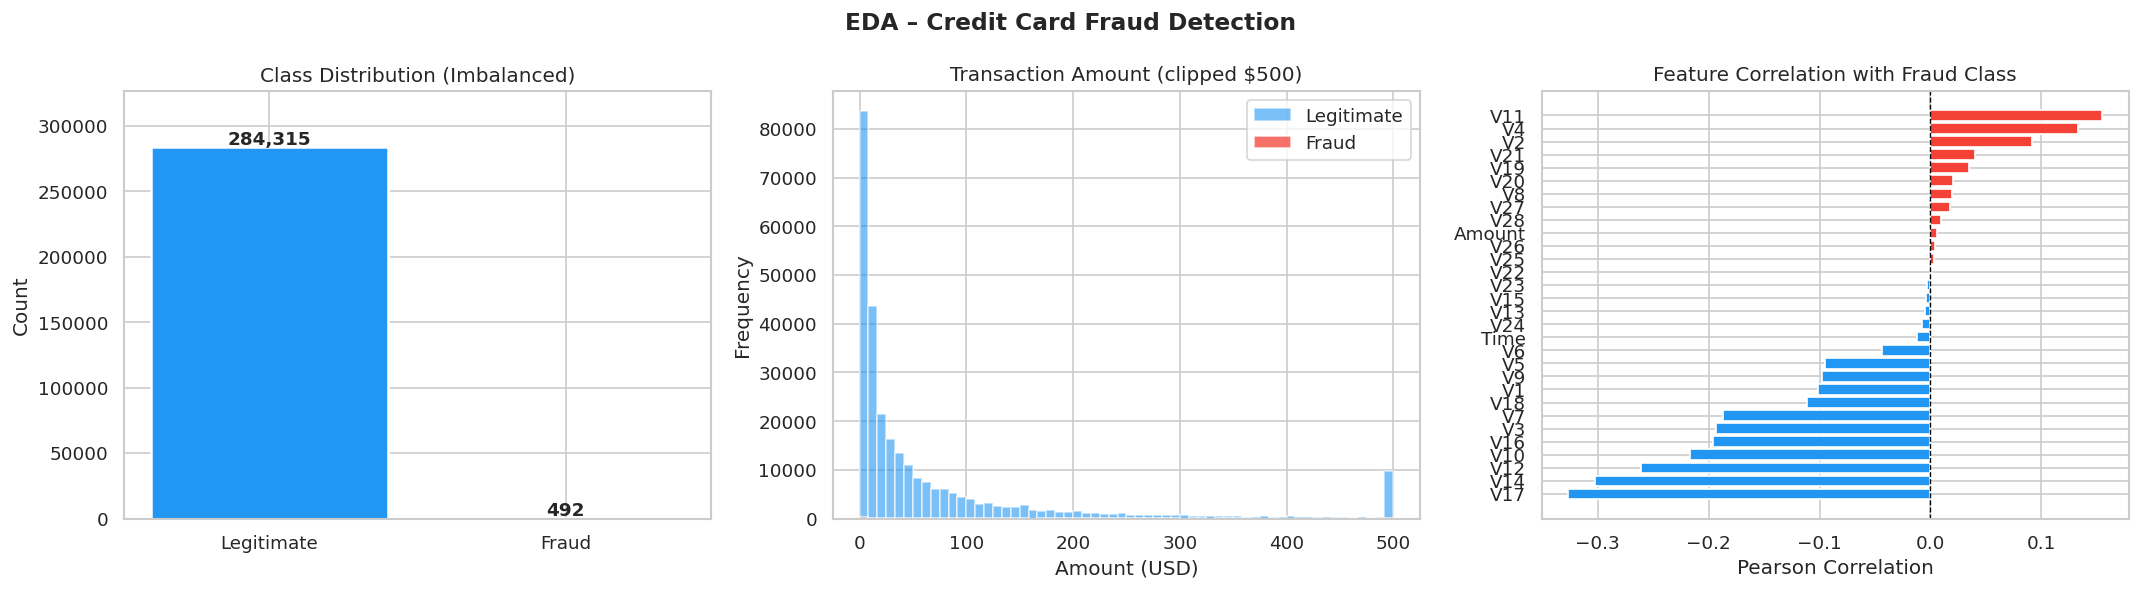

✅ EDA plot saved: eda_xgb.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA – Credit Card Fraud Detection', fontsize=14, fontweight='bold')

# 1. Class imbalance
counts = df['Class'].value_counts()
bars = axes[0].bar(['Legitimate', 'Fraud'], counts.values,
                    color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Imbalanced)')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1500,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, counts.max() * 1.15)

# 2. Transaction amount by class
df[df.Class==0]['Amount'].clip(upper=500).hist(
    ax=axes[1], bins=60, alpha=0.6, color='#2196F3', label='Legitimate')
df[df.Class==1]['Amount'].clip(upper=500).hist(
    ax=axes[1], bins=60, alpha=0.75, color='#F44336', label='Fraud')
axes[1].set_title('Transaction Amount (clipped $500)')
axes[1].set_xlabel('Amount (USD)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# 3. Feature correlation with Class
corr = df.corr()['Class'].drop('Class').sort_values()
colors_bar = ['#F44336' if v > 0 else '#2196F3' for v in corr.values]
axes[2].barh(corr.index, corr.values, color=colors_bar, edgecolor='white')
axes[2].axvline(0, color='black', lw=0.8, linestyle='--')
axes[2].set_title('Feature Correlation with Fraud Class')
axes[2].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('eda_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plot saved: eda_xgb.png')

## 🔧 Step 4 — Preprocessing (Scaling + SMOTE)

In [8]:
# Scale Amount and Time (V1-V28 are already PCA-transformed)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df.drop(columns=['Amount', 'Time'], inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'✅ Preprocessing complete')
print(f'   Train : {X_train.shape} | Fraud in train: {y_train.sum():,}')
print(f'   Test  : {X_test.shape}  | Fraud in test : {y_test.sum():,}')

✅ Preprocessing complete
   Train : (227845, 30) | Fraud in train: 394
   Test  : (56962, 30)  | Fraud in test : 98


In [9]:
# Apply SMOTE to training set ONLY (never on test set!)
print('Applying SMOTE to training set... (~30 seconds)')
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'✅ SMOTE complete')
print(f'   Before : {dict(pd.Series(y_train).value_counts())}')
print(f'   After  : {dict(pd.Series(y_train_res).value_counts())}')

# XGBoost can also handle imbalance natively via scale_pos_weight
# We'll use SMOTE + scale_pos_weight together for best results
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\n   scale_pos_weight (for XGBoost) : {scale_pos_weight:.1f}')

Applying SMOTE to training set... (~30 seconds)
✅ SMOTE complete
   Before : {0: np.int64(227451), 1: np.int64(394)}
   After  : {0: np.int64(227451), 1: np.int64(227451)}

   scale_pos_weight (for XGBoost) : 577.3


## 🚀 Step 5 — Train XGBoost with RandomizedSearchCV
> **Expected runtime: ~2–3 minutes** on Colab CPU ✅

In [10]:
param_dist = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [3, 5, 7, 9],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2],
    'subsample'         : [0.6, 0.8, 1.0],
    'colsample_bytree'  : [0.6, 0.8, 1.0],
    'min_child_weight'  : [1, 3, 5],
    'gamma'             : [0, 0.1, 0.3]
}

xgb_base = XGBClassifier(
    objective         = 'binary:logistic',
    scale_pos_weight  = scale_pos_weight,   # handles class imbalance natively
    eval_metric       = 'aucpr',            # area under PR curve
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
    tree_method       = 'hist'              # faster than exact on large data
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Starting RandomizedSearchCV...')
print('  20 iterations × 5 folds = 100 fits (~2–3 min)\n')

t0 = time.time()
rand_search = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter      = 20,
    cv          = cv,
    scoring     = 'f1',
    n_jobs      = -1,
    random_state= 42,
    verbose     = 1
)
rand_search.fit(X_train_res, y_train_res)
elapsed = time.time() - t0

print(f'\n✅ Training complete in {elapsed/60:.1f} minutes')
print(f'   Best params : {rand_search.best_params_}')
print(f'   Best CV F1  : {rand_search.best_score_:.4f}')

xgb_best = rand_search.best_estimator_

Starting RandomizedSearchCV...
  20 iterations × 5 folds = 100 fits (~2–3 min)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Training complete in 23.8 minutes
   Best params : {'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}
   Best CV F1  : 0.9995


## 📊 Step 6 — Evaluate on Test Set

In [11]:
y_pred = xgb_best.predict(X_test)
y_prob = xgb_best.predict_proba(X_test)[:, 1]

roc_auc  = roc_auc_score(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)
f1       = f1_score(y_test, y_pred)
acc      = accuracy_score(y_test, y_pred)

print('=' * 58)
print('        XGBoost EVALUATION RESULTS (Test Set)')
print('=' * 58)
print(f'  ROC-AUC Score       : {roc_auc:.4f}')
print(f'  Average Precision   : {avg_prec:.4f}')
print(f'  F1-Score (Fraud)    : {f1:.4f}')
print(f'  Overall Accuracy    : {acc:.4f}')
print('=' * 58)
print('\nClassification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))

        XGBoost EVALUATION RESULTS (Test Set)
  ROC-AUC Score       : 0.9628
  Average Precision   : 0.8660
  F1-Score (Fraud)    : 0.7319
  Overall Accuracy    : 0.9989

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.63      0.88      0.73        98

    accuracy                           1.00     56962
   macro avg       0.81      0.94      0.87     56962
weighted avg       1.00      1.00      1.00     56962



  True Negatives  (Legit correctly identified) : 56,813
  False Positives (Legit wrongly flagged)       : 51
  False Negatives (Fraud missed)                : 12
  True Positives  (Fraud correctly caught)      : 86


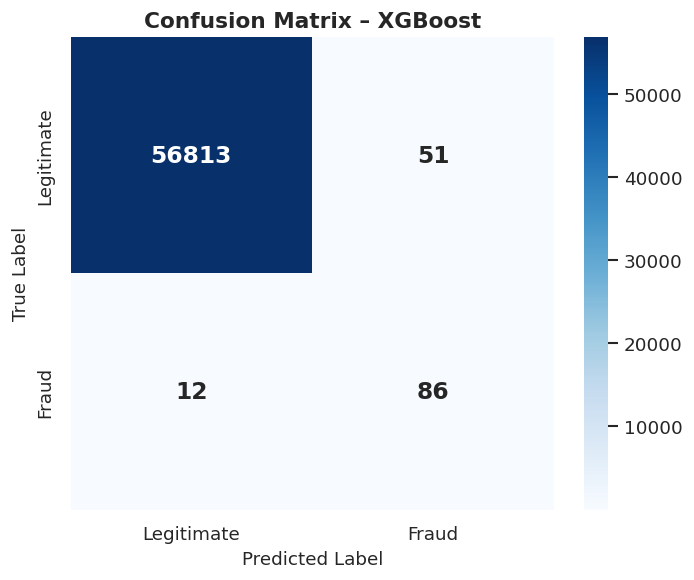

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Confusion Matrix – XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

tn, fp, fn, tp = cm.ravel()
print(f'  True Negatives  (Legit correctly identified) : {tn:,}')
print(f'  False Positives (Legit wrongly flagged)       : {fp:,}')
print(f'  False Negatives (Fraud missed)                : {fn:,}')
print(f'  True Positives  (Fraud correctly caught)      : {tp:,}')

plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

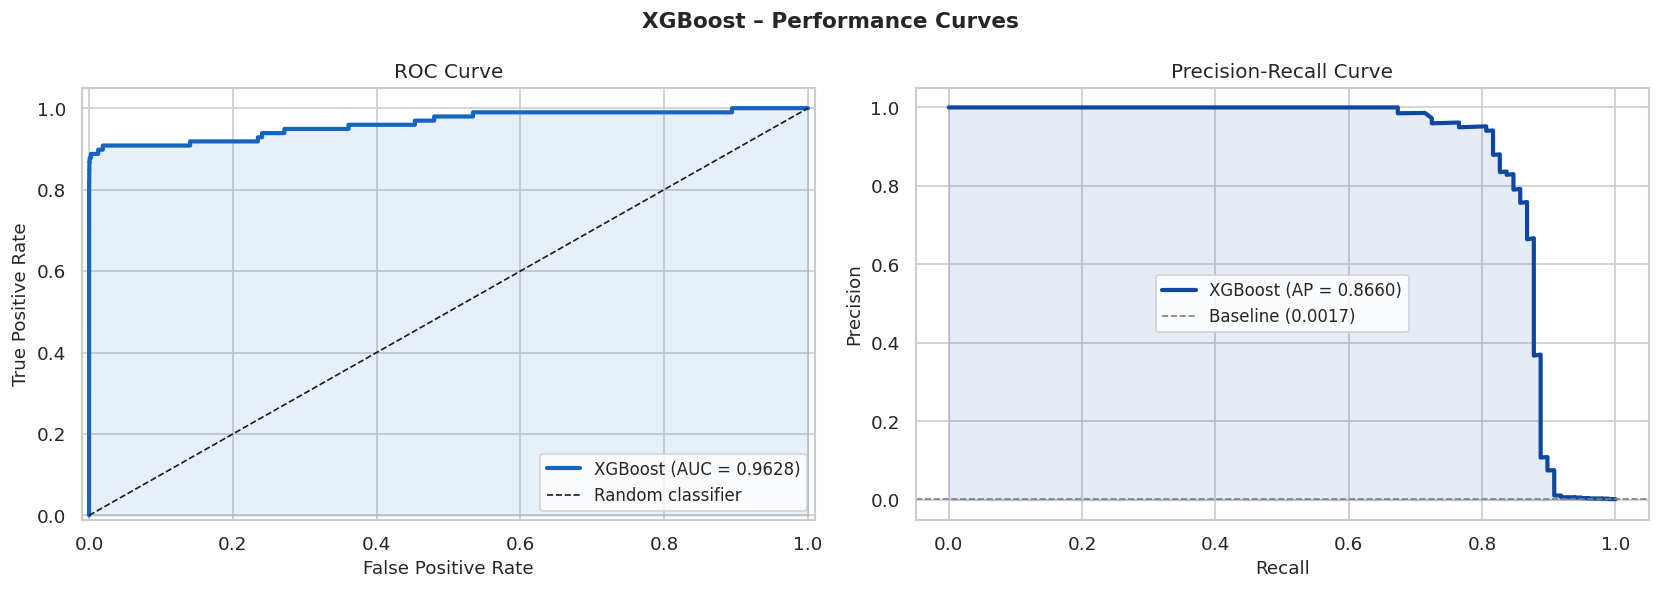

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost – Performance Curves', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#1565C0', lw=2.5,
             label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=10)
axes[0].set_xlim([-0.01, 1.01])
axes[0].set_ylim([-0.01, 1.05])

# Precision-Recall Curve
prec, rec, pr_thresh = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, color='#0D47A1', lw=2.5,
             label=f'XGBoost (AP = {avg_prec:.4f})')
axes[1].fill_between(rec, prec, alpha=0.1, color='#0D47A1')
baseline = y_test.sum() / len(y_test)
axes[1].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline ({baseline:.4f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('xgb_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

## 🌳 Step 7 — Feature Importance

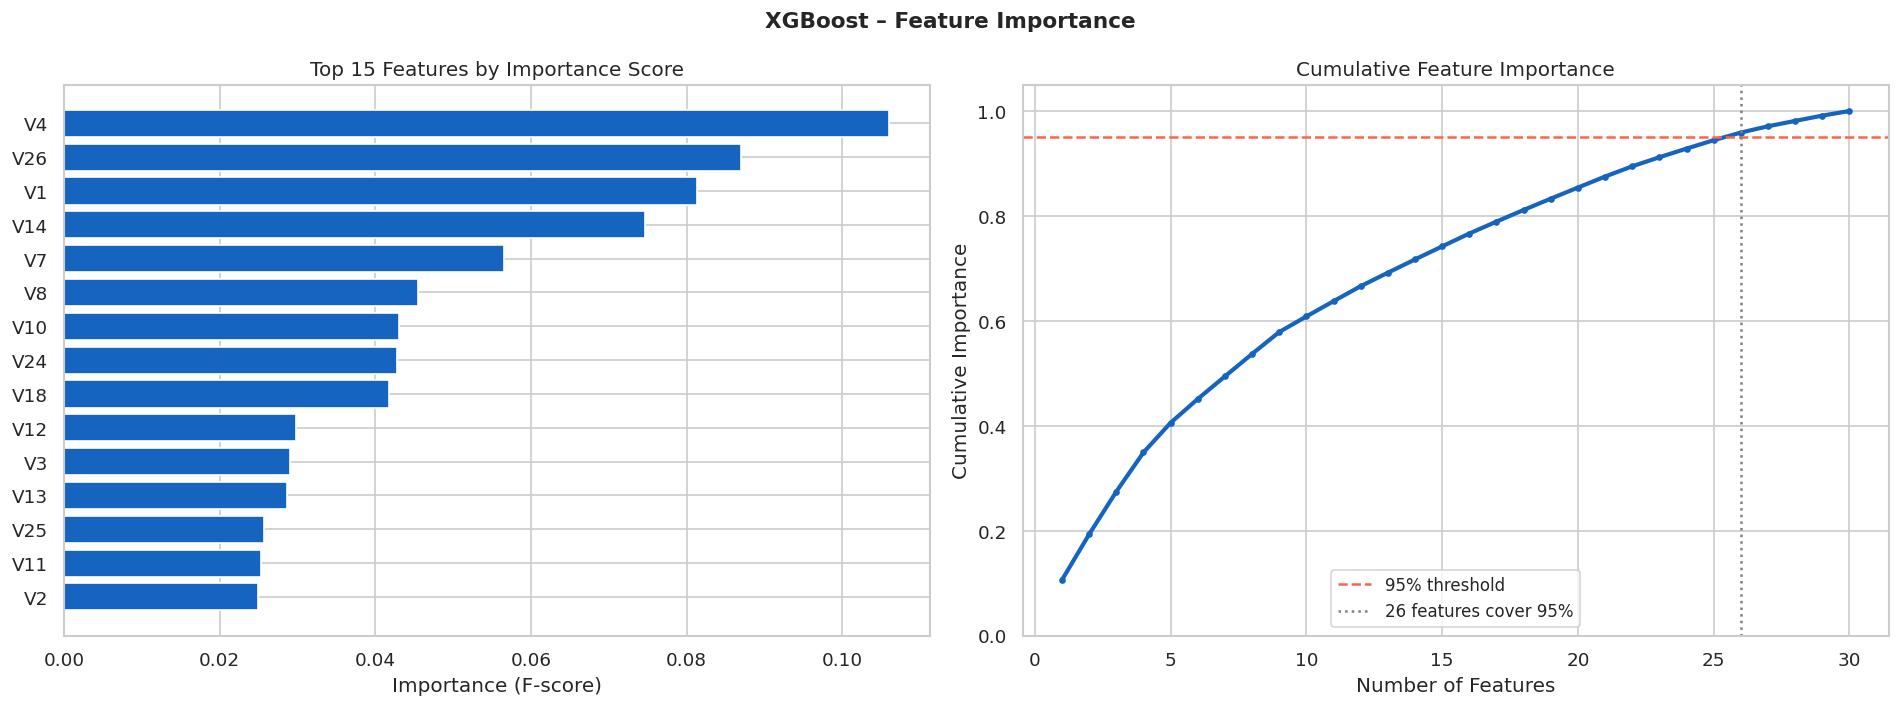

Top 10 most important features:
Feature  Importance
     V4    0.105992
    V26    0.086974
     V1    0.081335
    V14    0.074684
     V7    0.056540
     V8    0.045467
    V10    0.043058
    V24    0.042750
    V18    0.041779
    V12    0.029762


In [14]:
fi = pd.DataFrame({
    'Feature'    : X_test.columns,
    'Importance' : xgb_best.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XGBoost – Feature Importance', fontsize=13, fontweight='bold')

# Top 15 bar chart
top15 = fi.head(15)
axes[0].barh(top15['Feature'][::-1], top15['Importance'][::-1],
             color='#1565C0', edgecolor='white')
axes[0].set_title('Top 15 Features by Importance Score')
axes[0].set_xlabel('Importance (F-score)')

# Cumulative importance
fi_sorted = fi.copy()
fi_sorted['Cumulative'] = fi_sorted['Importance'].cumsum() / fi_sorted['Importance'].sum()
axes[1].plot(range(1, len(fi_sorted)+1), fi_sorted['Cumulative'],
             color='#1565C0', lw=2.5, marker='o', markersize=3)
axes[1].axhline(0.95, color='tomato', linestyle='--', lw=1.5, label='95% threshold')
n_95 = (fi_sorted['Cumulative'] <= 0.95).sum() + 1
axes[1].axvline(n_95, color='gray', linestyle=':', lw=1.5, label=f'{n_95} features cover 95%')
axes[1].set_title('Cumulative Feature Importance')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].legend(fontsize=10)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
print(fi.head(10).to_string(index=False))

## 🔬 Step 8 — Optimal Threshold Analysis

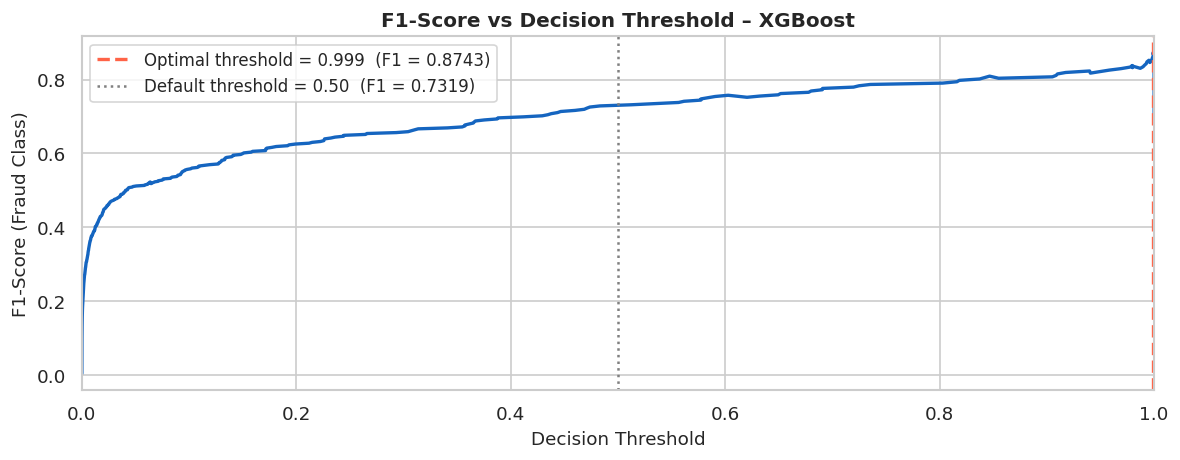

Optimal threshold : 0.9993
F1 at optimal     : 0.8743
F1 at default 0.5 : 0.7319

Classification Report at OPTIMAL threshold:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [15]:
# Find threshold that maximises F1-Score
f1_scores = []
for t in pr_thresh:
    y_pred_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

best_idx    = np.argmax(f1_scores)
best_thresh = pr_thresh[best_idx]
best_f1     = f1_scores[best_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pr_thresh, f1_scores, color='#1565C0', lw=2)
ax.axvline(best_thresh, color='tomato', linestyle='--', lw=2,
           label=f'Optimal threshold = {best_thresh:.3f}  (F1 = {best_f1:.4f})')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5,
           label=f'Default threshold = 0.50  (F1 = {f1:.4f})')
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('F1-Score (Fraud Class)', fontsize=11)
ax.set_title('F1-Score vs Decision Threshold – XGBoost', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
plt.tight_layout()
plt.savefig('xgb_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal threshold : {best_thresh:.4f}')
print(f'F1 at optimal     : {best_f1:.4f}')
print(f'F1 at default 0.5 : {f1:.4f}')

# Report using optimal threshold
y_pred_opt = (y_prob >= best_thresh).astype(int)
print('\nClassification Report at OPTIMAL threshold:')
print(classification_report(y_test, y_pred_opt,
      target_names=['Legitimate', 'Fraud']))

## 📈 Step 9 — Learning Curve (Training vs Validation)

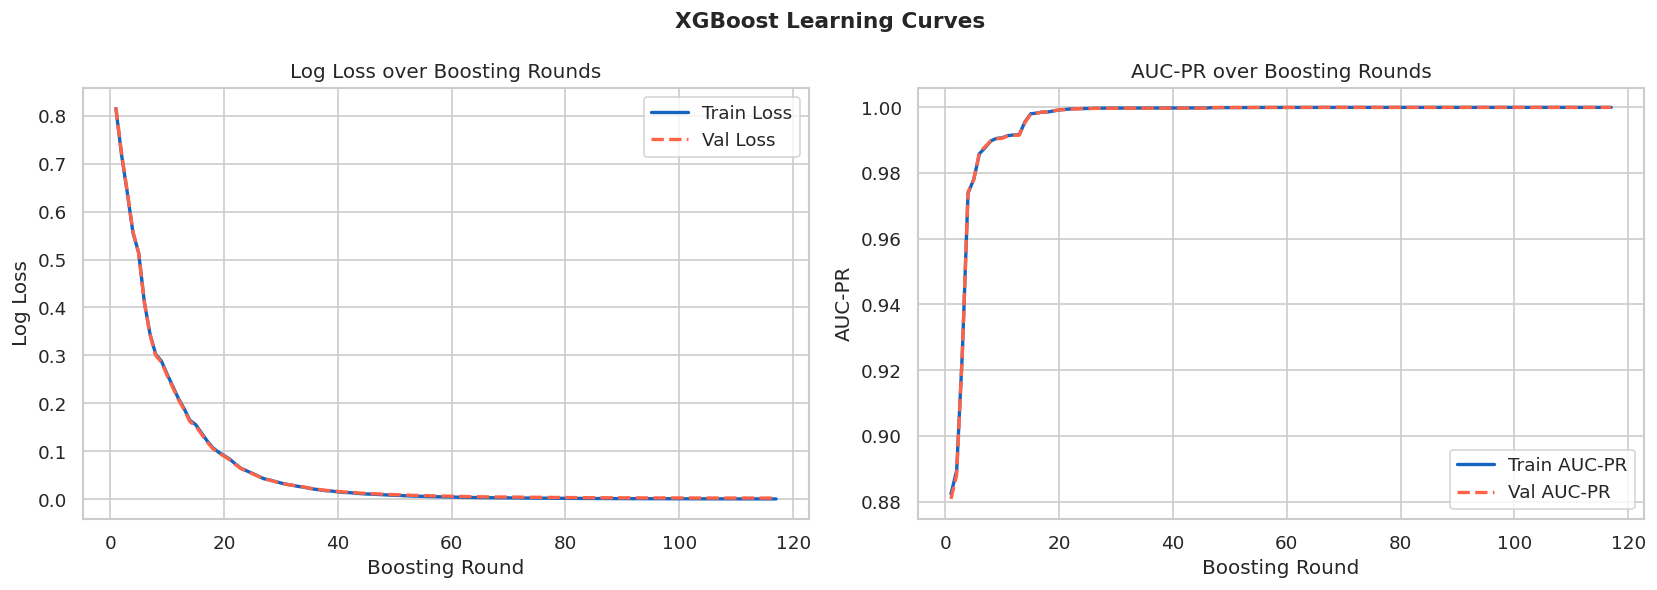

✅ Best round (early stopping): 96


In [16]:
# Train final model with eval tracking to plot learning curve
best_p = rand_search.best_params_

xgb_lc = XGBClassifier(
    **best_p,
    objective        = 'binary:logistic',
    scale_pos_weight = scale_pos_weight,
    eval_metric      = ['logloss', 'aucpr'],
    use_label_encoder= False,
    random_state     = 42,
    n_jobs           = -1,
    tree_method      = 'hist',
    early_stopping_rounds = 20
)

# Use a validation split from training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_res, y_train_res,
    test_size=0.1, random_state=42, stratify=y_train_res)

xgb_lc.fit(
    X_tr, y_tr,
    eval_set        = [(X_tr, y_tr), (X_val, y_val)],
    verbose         = False
)

results   = xgb_lc.evals_result()
train_loss= results['validation_0']['logloss']
val_loss  = results['validation_1']['logloss']
train_auc = results['validation_0']['aucpr']
val_auc   = results['validation_1']['aucpr']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost Learning Curves', fontsize=13, fontweight='bold')

epochs = range(1, len(train_loss)+1)
axes[0].plot(epochs, train_loss, label='Train Loss', color='#1565C0', lw=2)
axes[0].plot(epochs, val_loss,   label='Val Loss',   color='tomato',   lw=2, linestyle='--')
axes[0].set_title('Log Loss over Boosting Rounds')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('Log Loss')
axes[0].legend()

axes[1].plot(epochs, train_auc, label='Train AUC-PR', color='#1565C0', lw=2)
axes[1].plot(epochs, val_auc,   label='Val AUC-PR',   color='tomato',   lw=2, linestyle='--')
axes[1].set_title('AUC-PR over Boosting Rounds')
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('AUC-PR')
axes[1].legend()

plt.tight_layout()
plt.savefig('xgb_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Best round (early stopping): {xgb_lc.best_iteration}')

## 📋 Step 10 — Final Summary

In [17]:
print('=' * 60)
print('         XGBoost FINAL SUMMARY – MEMBER 4')
print('=' * 60)
print(f'  Algorithm          : XGBoost (Extreme Gradient Boosting)')
print(f'  n_estimators       : {xgb_best.n_estimators}')
print(f'  max_depth          : {xgb_best.max_depth}')
print(f'  learning_rate      : {xgb_best.learning_rate}')
print(f'  subsample          : {xgb_best.subsample}')
print(f'  colsample_bytree   : {xgb_best.colsample_bytree}')
print(f'  scale_pos_weight   : {scale_pos_weight:.1f}')
print(f'  Training samples   : {len(y_train_res):,} (after SMOTE)')
print(f'  Test samples       : {len(y_test):,}')
print(f'  ROC-AUC            : {roc_auc:.4f}')
print(f'  Average Precision  : {avg_prec:.4f}')
print(f'  F1-Score (default) : {f1:.4f}   [threshold = 0.5]')
print(f'  F1-Score (optimal) : {best_f1:.4f}   [threshold = {best_thresh:.3f}]')
print('=' * 60)

print('\nCOMPARISON TABLE (fill in from other notebooks):')
comp = pd.DataFrame({
    'Algorithm'     : ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'ROC-AUC'       : ['[fill]', '[fill]', '[fill]', f'{roc_auc:.4f}'],
    'Avg Precision' : ['[fill]', '[fill]', '[fill]', f'{avg_prec:.4f}'],
    'F1-Score'      : ['[fill]', '[fill]', '[fill]', f'{f1:.4f}'],
})
print(comp.to_string(index=False))

         XGBoost FINAL SUMMARY – MEMBER 4
  Algorithm          : XGBoost (Extreme Gradient Boosting)
  n_estimators       : 300
  max_depth          : 9
  learning_rate      : 0.2
  subsample          : 0.6
  colsample_bytree   : 1.0
  scale_pos_weight   : 577.3
  Training samples   : 454,902 (after SMOTE)
  Test samples       : 56,962
  ROC-AUC            : 0.9628
  Average Precision  : 0.8660
  F1-Score (default) : 0.7319   [threshold = 0.5]
  F1-Score (optimal) : 0.8743   [threshold = 0.999]

COMPARISON TABLE (fill in from other notebooks):
          Algorithm ROC-AUC Avg Precision F1-Score
Logistic Regression  [fill]        [fill]   [fill]
      Decision Tree  [fill]        [fill]   [fill]
      Random Forest  [fill]        [fill]   [fill]
            XGBoost  0.9628        0.8660   0.7319


## 💾 Step 11 — Download All Outputs

In [18]:
import os, zipfile
from google.colab import files

output_files = [
    'eda_xgb.png',
    'xgb_confusion_matrix.png',
    'xgb_roc_pr.png',
    'xgb_feature_importance.png',
    'xgb_threshold.png',
    'xgb_learning_curve.png',
]

with zipfile.ZipFile('xgb_outputs.zip', 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'  ✅ {f}')
        else:
            print(f'  ⚠️  Not found: {f}')

print('\n⬇️  Downloading xgb_outputs.zip...')
files.download('xgb_outputs.zip')

  ✅ eda_xgb.png
  ✅ xgb_confusion_matrix.png
  ✅ xgb_roc_pr.png
  ✅ xgb_feature_importance.png
  ✅ xgb_threshold.png
  ✅ xgb_learning_curve.png

⬇️  Downloading xgb_outputs.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>